<a href="https://colab.research.google.com/github/JosephNalkara/legal-case-outcome-predictor/blob/main/legal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# CELL 1 — Install Dependencies (run this FIRST, then wait for it to finish)
!pip install lime transformers datasets sentencepiece scikit-learn pandas matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 21.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# CELL 2 — Imports
# ────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string

warnings.filterwarnings("ignore")

# NLP & ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# NLTK
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# LIME for Explainability (XAI)
from lime.lime_text import LimeTextExplainer

# Transformers (BART for Summarization)
from transformers import pipeline

print("✅ All libraries imported successfully!")


# ────────────────────────────────────────────────────────────

✅ All libraries imported successfully!


In [4]:
# CELL 3 — Load & Explore Dataset
# ────────────────────────────────────────────────────────────

# Upload your CSV in Colab using the Files panel (left sidebar)
# then update the path below if needed.
CSV_PATH = "legal_cases_600_with_descriptions.csv"

df = pd.read_csv(CSV_PATH)

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total records : {len(df)}")
print(f"Columns       : {df.columns.tolist()}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

print("\n--- Sample Records ---")
df.head(3)


# ───────────────────────────────────────────────

DATASET OVERVIEW
Total records : 600
Columns       : ['case_id', 'crime_category', 'ipc_section', 'case_facts', 'evidence_strength', 'number_of_witnesses', 'accused_prior_record', 'punishment_years', 'fine_amount', 'verdict', 'case_description']

Column dtypes:
case_id                  int64
crime_category          object
ipc_section              int64
case_facts              object
evidence_strength       object
number_of_witnesses      int64
accused_prior_record    object
punishment_years         int64
fine_amount              int64
verdict                 object
case_description        object
dtype: object

Missing values:
case_id                 0
crime_category          0
ipc_section             0
case_facts              0
evidence_strength       0
number_of_witnesses     0
accused_prior_record    0
punishment_years        0
fine_amount             0
verdict                 0
case_description        0
dtype: int64

--- Sample Records ---


,case_id,crime_category,ipc_section,case_facts,evidence_strength,number_of_witnesses,accused_prior_record,punishment_years,fine_amount,verdict,case_description
0,1,Theft,379,The accused was charged with theft under IPC s...,Weak,5,No,2,5572,Convicted,This case involves a charge of Theft under IPC...
1,2,Theft,379,The accused was charged with theft under IPC s...,Strong,5,Yes,5,28651,Convicted,This case involves a charge of Theft under IPC...
2,3,Murder,302,The accused was charged with murder under IPC ...,Weak,0,Yes,10,19390,Convicted,This case involves a charge of Murder under IP...


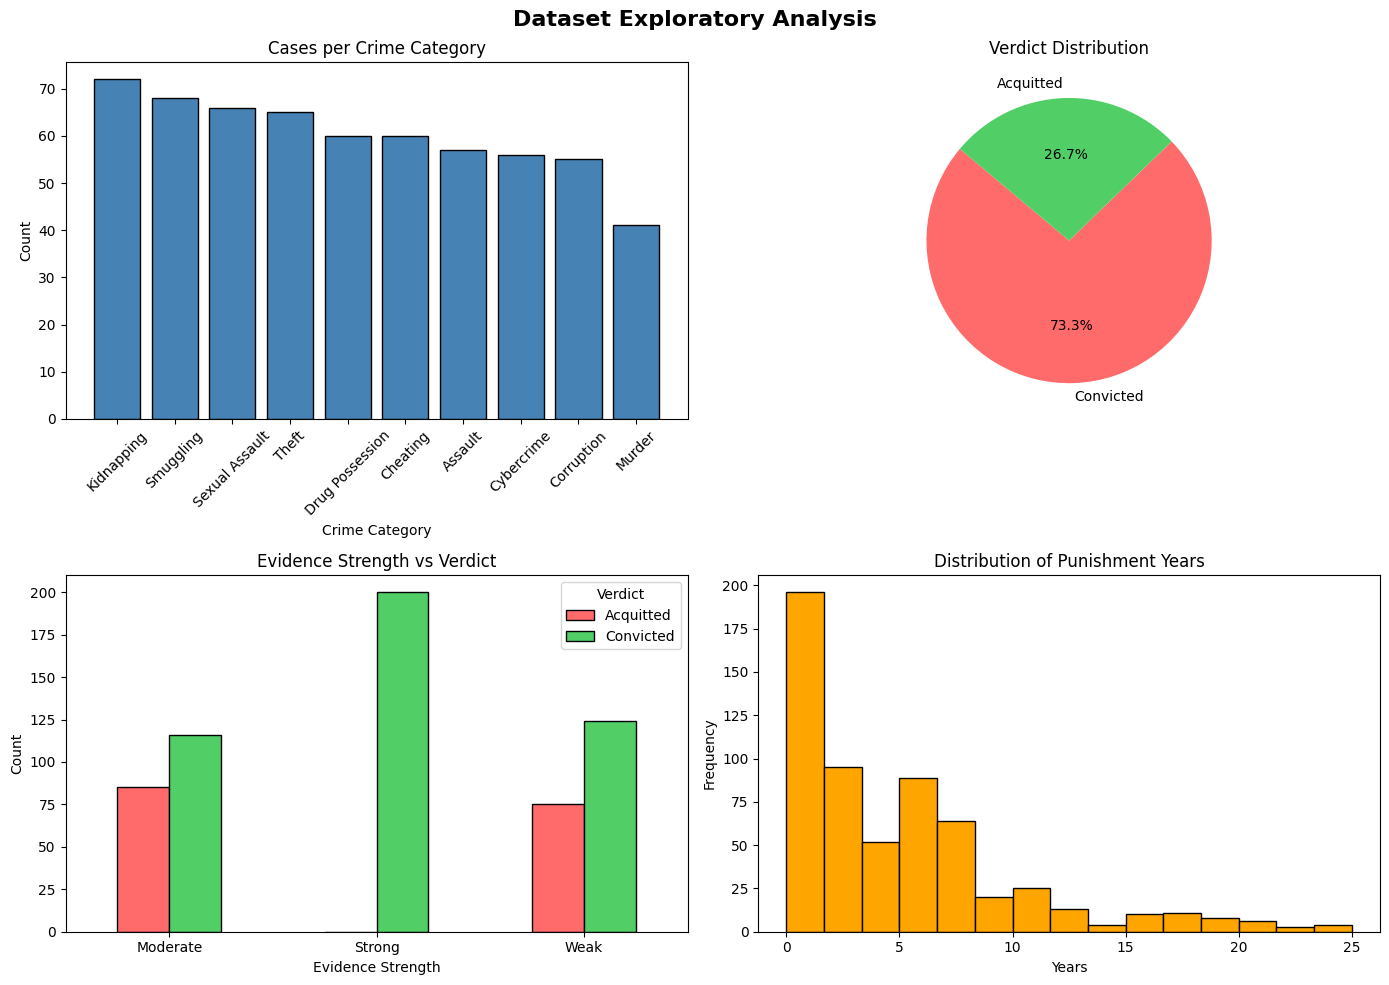

✅ EDA complete.


In [5]:
# CELL 4 — Exploratory Data Analysis (EDA)
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset Exploratory Analysis", fontsize=16, fontweight="bold")

# 1. Crime category distribution
crime_counts = df["crime_category"].value_counts()
axes[0, 0].bar(crime_counts.index, crime_counts.values, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Cases per Crime Category")
axes[0, 0].set_xlabel("Crime Category")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Verdict distribution
verdict_counts = df["verdict"].value_counts()
axes[0, 1].pie(verdict_counts.values, labels=verdict_counts.index,
               autopct="%1.1f%%", colors=["#ff6b6b", "#51cf66"], startangle=140)
axes[0, 1].set_title("Verdict Distribution")

# 3. Evidence strength vs verdict
evidence_verdict = df.groupby(["evidence_strength", "verdict"]).size().unstack(fill_value=0)
evidence_verdict.plot(kind="bar", ax=axes[1, 0], color=["#ff6b6b", "#51cf66"], edgecolor="black")
axes[1, 0].set_title("Evidence Strength vs Verdict")
axes[1, 0].set_xlabel("Evidence Strength")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(title="Verdict")

# 4. Punishment years distribution
axes[1, 1].hist(df["punishment_years"], bins=15, color="orange", edgecolor="black")
axes[1, 1].set_title("Distribution of Punishment Years")
axes[1, 1].set_xlabel("Years")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA complete.")


# ────────────────────────────────────────────────────────────

In [6]:
# CELL 5 — Text Preprocessing Utilities
# ────────────────────────────────────────────────────────────

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    """
    Full NLP preprocessing pipeline:
    lowercase → remove punctuation → tokenize
    → remove stopwords → lemmatize
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)           # remove non-alpha
    text = re.sub(r"\s+", " ", text).strip()         # collapse spaces
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

def anonymize_text(text: str, petitioner: str = "", respondent: str = "") -> str:
    """
    Replace petitioner/respondent names with generic placeholders.
    Falls back to a simple name-pattern removal if names not provided.
    """
    if petitioner:
        text = re.sub(re.escape(petitioner), "PETITIONER", text, flags=re.IGNORECASE)
    if respondent:
        text = re.sub(re.escape(respondent), "RESPONDENT", text, flags=re.IGNORECASE)
    # Also mask common IPC-specific accused references
    text = re.sub(r"\bthe accused\b", "ACCUSED", text, flags=re.IGNORECASE)
    return text

# Apply preprocessing to the main text columns
print("Preprocessing text columns...")
df["processed_facts"]       = df["case_facts"].apply(preprocess_text)
df["processed_description"] = df["case_description"].apply(preprocess_text)

print(f"Sample original : {df['case_facts'].iloc[0][:100]}")
print(f"Sample processed: {df['processed_facts'].iloc[0][:100]}")
print("✅ Text preprocessing done.")


# ════════════════════════════════════════════════════════════
# MODULE 1 — IPC SECTION & PUNISHMENT PREDICTION
# (TF-IDF + Random Forest Classifier)
# ════════════════════════════════════════════════════════════

Preprocessing text columns...
Sample original : The accused was charged with theft under IPC section 379. Evidence strength was Weak. 5 witnesses we
Sample processed: accused charged theft ipc section evidence strength weak witness presented court prior criminal reco
✅ Text preprocessing done.


In [7]:
# CELL 6 — Prepare Data for IPC Prediction
# ────────────────────────────────────────────────────────────

# Encode IPC section as string labels (multi-class classification)
df["ipc_label"] = df["ipc_section"].astype(str)

X_ipc = df["processed_facts"]
y_ipc = df["ipc_label"]

X_ipc_train, X_ipc_test, y_ipc_train, y_ipc_test = train_test_split(
    X_ipc, y_ipc, test_size=0.2, random_state=42, stratify=y_ipc
)

print(f"IPC Train size : {len(X_ipc_train)}")
print(f"IPC Test size  : {len(X_ipc_test)}")
print(f"IPC Classes    : {sorted(y_ipc.unique())}")


# ────────────────────────────────────────────────────────────

IPC Train size : 480
IPC Test size  : 120
IPC Classes    : ['13', '135', '21', '302', '323', '363', '376', '379', '420', '66']


In [8]:
# CELL 7 — TF-IDF Vectorizer for IPC Module
# ────────────────────────────────────────────────────────────

ipc_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,
    sublinear_tf=True      # apply log normalization
)

X_ipc_train_vec = ipc_tfidf.fit_transform(X_ipc_train)
X_ipc_test_vec  = ipc_tfidf.transform(X_ipc_test)

print(f"TF-IDF feature matrix: {X_ipc_train_vec.shape}")


# ────────────────────────────────────────────────────────────

TF-IDF feature matrix: (480, 64)


In [9]:
# CELL 8 — Train Random Forest for IPC Prediction
# ────────────────────────────────────────────────────────────

ipc_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

ipc_rf_model.fit(X_ipc_train_vec, y_ipc_train)

y_ipc_pred = ipc_rf_model.predict(X_ipc_test_vec)

print("=" * 55)
print("MODULE 1 — IPC SECTION PREDICTION RESULTS")
print("=" * 55)
print(f"Overall Accuracy: {accuracy_score(y_ipc_test, y_ipc_pred):.4f}")
print()
print(classification_report(y_ipc_test, y_ipc_pred))


# ────────────────────────────────────────────────────────────

MODULE 1 — IPC SECTION PREDICTION RESULTS
Overall Accuracy: 1.0000

              precision    recall  f1-score   support

          13       1.00      1.00      1.00        11
         135       1.00      1.00      1.00        14
          21       1.00      1.00      1.00        12
         302       1.00      1.00      1.00         8
         323       1.00      1.00      1.00        11
         363       1.00      1.00      1.00        15
         376       1.00      1.00      1.00        13
         379       1.00      1.00      1.00        13
         420       1.00      1.00      1.00        12
          66       1.00      1.00      1.00        11

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



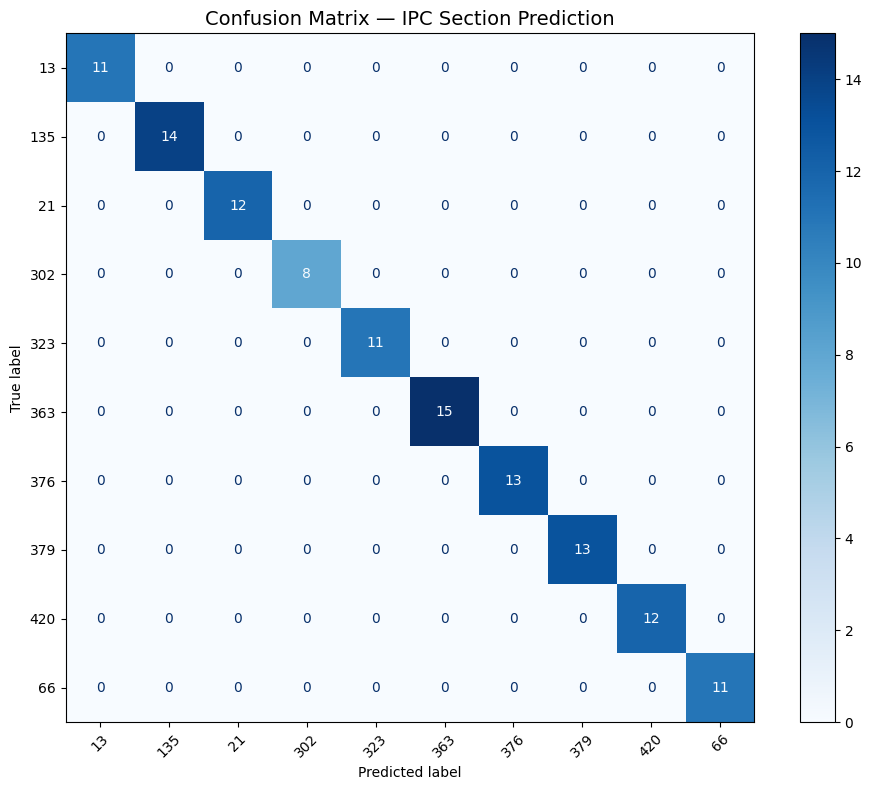

In [10]:
# CELL 9 — IPC Confusion Matrix
# ────────────────────────────────────────────────────────────

cm_ipc = confusion_matrix(y_ipc_test, y_ipc_pred, labels=ipc_rf_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ipc, display_labels=ipc_rf_model.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Confusion Matrix — IPC Section Prediction", fontsize=14)
plt.tight_layout()
plt.savefig("ipc_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


# ────────────────────────────────────────────────────────────

In [11]:
# CELL 10 — Punishment Prediction (punishment_years as category)
# ────────────────────────────────────────────────────────────

# Bin punishment years into categories for classification
def bin_punishment(years):
    if years <= 2:
        return "Short (0-2 yrs)"
    elif years <= 5:
        return "Medium (3-5 yrs)"
    elif years <= 10:
        return "Long (6-10 yrs)"
    else:
        return "Life/Severe (10+ yrs)"

df["punishment_category"] = df["punishment_years"].apply(bin_punishment)

X_pun = df["processed_facts"]
y_pun = df["punishment_category"]

X_pun_train, X_pun_test, y_pun_train, y_pun_test = train_test_split(
    X_pun, y_pun, test_size=0.2, random_state=42, stratify=y_pun
)

pun_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_pun_train_vec = pun_tfidf.fit_transform(X_pun_train)
X_pun_test_vec  = pun_tfidf.transform(X_pun_test)

pun_rf_model = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"
)
pun_rf_model.fit(X_pun_train_vec, y_pun_train)
y_pun_pred = pun_rf_model.predict(X_pun_test_vec)

print("=" * 55)
print("MODULE 1b — PUNISHMENT CATEGORY PREDICTION RESULTS")
print("=" * 55)
print(f"Overall Accuracy: {accuracy_score(y_pun_test, y_pun_pred):.4f}")
print()
print(classification_report(y_pun_test, y_pun_pred))


# ════════════════════════════════════════════════════════════

MODULE 1b — PUNISHMENT CATEGORY PREDICTION RESULTS
Overall Accuracy: 0.5833

                       precision    recall  f1-score   support

Life/Severe (10+ yrs)       0.56      0.77      0.65        13
      Long (6-10 yrs)       0.44      0.54      0.48        26
     Medium (3-5 yrs)       0.58      0.56      0.57        32
      Short (0-2 yrs)       0.72      0.57      0.64        49

             accuracy                           0.58       120
            macro avg       0.57      0.61      0.58       120
         weighted avg       0.60      0.58      0.59       120



In [12]:
# CELL 11 — Prepare Data for Verdict Prediction
# ────────────────────────────────────────────────────────────

# Encode verdict: Convicted=1, Acquitted=0
le_verdict = LabelEncoder()
df["verdict_encoded"] = le_verdict.fit_transform(df["verdict"])

# Anonymize and use case_facts as input
df["anon_facts"] = df["case_facts"].apply(lambda x: anonymize_text(x))
df["processed_anon_facts"] = df["anon_facts"].apply(preprocess_text)

X_verdict = df["processed_anon_facts"]
y_verdict  = df["verdict_encoded"]

X_v_train, X_v_test, y_v_train, y_v_test = train_test_split(
    X_verdict, y_verdict, test_size=0.2, random_state=42, stratify=y_verdict
)

print(f"Verdict Train size : {len(X_v_train)}")
print(f"Verdict Test size  : {len(X_v_test)}")
print(f"Class balance:\n{pd.Series(y_verdict).value_counts()}")


# ────────────────────────────────────────────────────────────

Verdict Train size : 480
Verdict Test size  : 120
Class balance:
verdict_encoded
1    440
0    160
Name: count, dtype: int64


In [13]:
# CELL 12 — TF-IDF + Random Forest for Verdict Prediction
# ────────────────────────────────────────────────────────────

verdict_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_v_train_vec = verdict_tfidf.fit_transform(X_v_train)
X_v_test_vec  = verdict_tfidf.transform(X_v_test)

verdict_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

verdict_rf_model.fit(X_v_train_vec, y_v_train)
y_v_pred = verdict_rf_model.predict(X_v_test_vec)

print("=" * 55)
print("MODULE 2 — VERDICT PREDICTION RESULTS")
print("=" * 55)
print(f"Overall Accuracy: {accuracy_score(y_v_test, y_v_pred):.4f}")
print()
print(classification_report(y_v_test, y_v_pred,
                             target_names=le_verdict.classes_))


# ────────────────────────────────────────────────────────────

MODULE 2 — VERDICT PREDICTION RESULTS
Overall Accuracy: 0.6583

              precision    recall  f1-score   support

   Acquitted       0.43      0.91      0.59        32
   Convicted       0.94      0.57      0.71        88

    accuracy                           0.66       120
   macro avg       0.69      0.74      0.65       120
weighted avg       0.81      0.66      0.68       120



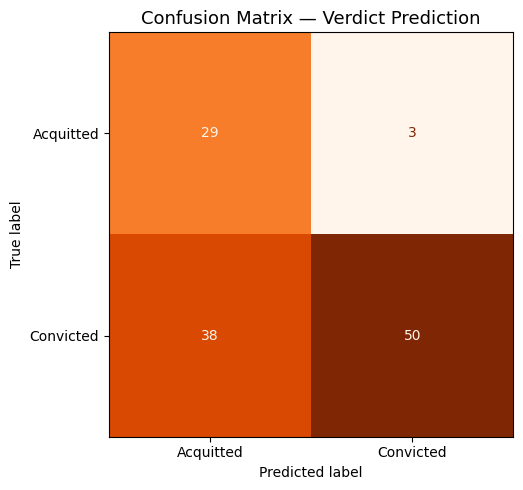

In [14]:
# CELL 13 — Verdict Confusion Matrix
# ────────────────────────────────────────────────────────────

cm_v = confusion_matrix(y_v_test, y_v_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_v,
                               display_labels=le_verdict.classes_)
disp.plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Confusion Matrix — Verdict Prediction", fontsize=13)
plt.tight_layout()
plt.savefig("verdict_confusion_matrix.png", dpi=150)
plt.show()


# ────────────────────────────────────────────────────────────


--- LIME Explanation for Test Sample #5 ---
True label : Convicted
Predicted  : Convicted

Top influential words:
  strong                     weight=+0.3374  → Convicted
  witness                    weight=+0.0941  → Convicted
  strength                   weight=+0.0925  → Convicted
  yes                        weight=+0.0415  → Convicted
  record                     weight=+0.0303  → Convicted
  charged                    weight=-0.0144  → Acquitted
  theft                      weight=+0.0141  → Convicted
  presented                  weight=+0.0107  → Convicted
  accused                    weight=-0.0084  → Acquitted
  prior                      weight=-0.0082  → Acquitted


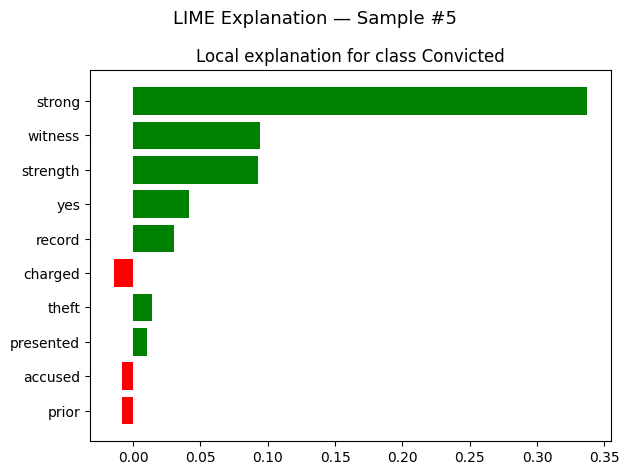

In [15]:
# CELL 14 — LIME XAI: Explain a Verdict Prediction
# ────────────────────────────────────────────────────────────

def predict_proba_for_lime(texts):
    """
    LIME needs a function: list[str] → numpy array of probabilities.
    """
    vecs = verdict_tfidf.transform(texts)
    return verdict_rf_model.predict_proba(vecs)

lime_explainer = LimeTextExplainer(
    class_names=list(le_verdict.classes_),
    random_state=42
)

# Pick a test sample to explain
sample_idx = 5
sample_text = X_v_test.iloc[sample_idx]
true_label  = le_verdict.inverse_transform([y_v_test.iloc[sample_idx]])[0]

exp = lime_explainer.explain_instance(
    sample_text,
    predict_proba_for_lime,
    num_features=10,
    num_samples=500
)

print(f"\n--- LIME Explanation for Test Sample #{sample_idx} ---")
print(f"True label : {true_label}")
pred_label = le_verdict.inverse_transform(
    [verdict_rf_model.predict(verdict_tfidf.transform([sample_text]))[0]]
)[0]
print(f"Predicted  : {pred_label}")
print(f"\nTop influential words:")
for word, weight in exp.as_list():
    direction = "→ Convicted" if weight > 0 else "→ Acquitted"
    print(f"  {word:25s}  weight={weight:+.4f}  {direction}")

# Show LIME plot
fig = exp.as_pyplot_figure()
fig.suptitle(f"LIME Explanation — Sample #{sample_idx}", fontsize=13)
plt.tight_layout()
plt.savefig("lime_explanation.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════

In [17]:
# CELL 15 — Fixed: Load BART Summarizer
from transformers import BartForConditionalGeneration, BartTokenizer
import torch

print("Loading BART summarization model...")
print("(This may take 2-3 minutes on first run — downloads ~1.6GB)")

MODEL_NAME = "facebook/bart-large-cnn"

bart_tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
bart_model     = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bart_model = bart_model.to(device)
bart_model.eval()

print(f"✅ BART model loaded! Running on: {device}")

Loading BART summarization model...
(This may take 2-3 minutes on first run — downloads ~1.6GB)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

✅ BART model loaded! Running on: cuda


In [18]:
# CELL 16 — Fixed: summarize_case using direct BartTokenizer

def summarize_case(text: str, max_len: int = 150, min_len: int = 40) -> str:
    words = text.split()
    if len(words) > 900:
        text = " ".join(words[:900])

    inputs = bart_tokenizer(
        text,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    ).to(device)

    with torch.no_grad():
        summary_ids = bart_model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=max_len,
            min_length=min_len,
            early_stopping=True
        )

    return bart_tokenizer.decode(summary_ids[0], skip_special_tokens=True)


# Demo on a few samples
print("=" * 55)
print("MODULE 3 — CASE SUMMARIZATION DEMO")
print("=" * 55)

for i in [0, 50, 200]:
    original = df["case_description"].iloc[i]
    summary  = summarize_case(original)
    crime    = df["crime_category"].iloc[i]
    ipc      = df["ipc_section"].iloc[i]

    print(f"\n[Case #{i}] Crime: {crime} | IPC: {ipc}")
    print(f"Original ({len(original.split())} words):\n  {original[:200]}...")
    print(f"\nSummary  ({len(summary.split())} words):\n  {summary}")
    print("-" * 55)

MODULE 3 — CASE SUMMARIZATION DEMO

[Case #0] Crime: Theft | IPC: 379
Original (48 words):
  This case involves a charge of Theft under IPC section 379. The prosecution presented evidence considered Weak in strength with testimony from 5 witnesses. The accused had no prior criminal record. Ba...

Summary  (41 words):
  This case involves a charge of Theft under IPC section 379. The prosecution presented evidence considered Weak in strength with testimony from 5 witnesses. Based on the evaluation of the facts and evidence, the accused was ultimately convicted by the court.
-------------------------------------------------------

[Case #50] Crime: Smuggling | IPC: 135
Original (48 words):
  This case involves a charge of Smuggling under IPC section 135. The prosecution presented evidence considered Weak in strength with testimony from 4 witnesses. The accused had no prior criminal record...

Summary  (41 words):
  This case involves a charge of Smuggling under IPC section 135. The prosec

In [19]:
# CELL 17 — Combined Prediction Function

def predict_full_case(
    case_facts: str,
    petitioner: str = "Petitioner",
    respondent: str = "State",
    run_summary: bool = True
):
    print("\n" + "=" * 60)
    print("  AI LEGAL ASSISTANT — CASE ANALYSIS REPORT")
    print("=" * 60)
    print(f"\nPetitioner : {petitioner}")
    print(f"Respondent : {respondent}")
    print(f"\nCase Facts :\n  {case_facts[:300]}{'...' if len(case_facts) > 300 else ''}")

    # Step 1 — Anonymize & Preprocess
    anon_text  = anonymize_text(case_facts, petitioner, respondent)
    clean_text = preprocess_text(anon_text)

    # Step 2 — IPC Section Prediction
    ipc_vec  = ipc_tfidf.transform([clean_text])
    ipc_pred = ipc_rf_model.predict(ipc_vec)[0]
    ipc_prob = ipc_rf_model.predict_proba(ipc_vec).max()

    # Step 3 — Punishment Category Prediction
    pun_vec  = pun_tfidf.transform([clean_text])
    pun_pred = pun_rf_model.predict(pun_vec)[0]

    # Step 4 — Verdict Prediction with Probabilities
    v_vec   = verdict_tfidf.transform([clean_text])
    v_proba = verdict_rf_model.predict_proba(v_vec)[0]
    v_pred  = verdict_rf_model.predict(v_vec)[0]
    v_label = le_verdict.inverse_transform([v_pred])[0]

    convicted_prob = v_proba[list(le_verdict.classes_).index("Convicted")] * 100
    acquitted_prob = v_proba[list(le_verdict.classes_).index("Acquitted")] * 100

    # Step 5 — LIME Explanation
    exp = lime_explainer.explain_instance(
        clean_text,
        predict_proba_for_lime,
        num_features=8,
        num_samples=300
    )
    top_words = exp.as_list()

    # Step 6 — Summarization (optional)
    summary = ""
    if run_summary:
        summary = summarize_case(case_facts)

    # Print Report
    print("\n" + "─" * 60)
    print("  📋 APPLICABLE IPC SECTION")
    print("─" * 60)
    print(f"  Predicted IPC Section : {ipc_pred}  (confidence: {ipc_prob:.1%})")

    print("\n" + "─" * 60)
    print("  ⚖️  PREDICTED PUNISHMENT")
    print("─" * 60)
    print(f"  Punishment Category : {pun_pred}")

    print("\n" + "─" * 60)
    print("  🏛️  CASE OUTCOME PREDICTION")
    print("─" * 60)
    print(f"  Convicted  probability : {convicted_prob:.2f}%")
    print(f"  Acquitted  probability : {acquitted_prob:.2f}%")
    print(f"  Predicted Verdict      : ➤  {v_label.upper()}")

    print("\n" + "─" * 60)
    print("  🔍 KEY INFLUENTIAL WORDS (LIME XAI)")
    print("─" * 60)
    for word, weight in top_words[:8]:
        bar = "█" * int(abs(weight) * 100)
        direction = "Convicted ↑" if weight > 0 else "Acquitted ↑"
        print(f"  {word:20s}  {direction}  {bar}")

    if summary:
        print("\n" + "─" * 60)
        print("  📝 CASE SUMMARY (BART)")
        print("─" * 60)
        print(f"  {summary}")

    print("\n" + "=" * 60)

    return {
        "ipc_section"        : ipc_pred,
        "ipc_confidence"     : ipc_prob,
        "punishment_category": pun_pred,
        "verdict"            : v_label,
        "convicted_prob"     : convicted_prob,
        "acquitted_prob"     : acquitted_prob,
        "lime_words"         : top_words,
        "summary"            : summary
    }

print("✅ predict_full_case() function defined.")

✅ predict_full_case() function defined.


In [20]:
# CELL 18A — Test on a real case from the dataset

sample = df.iloc[10]

result = predict_full_case(
    case_facts  = sample["case_facts"],
    petitioner  = "Prosecution",
    respondent  = "Accused",
    run_summary = True
)


  AI LEGAL ASSISTANT — CASE ANALYSIS REPORT

Petitioner : Prosecution
Respondent : Accused

Case Facts :
  The accused was charged with theft under IPC section 379. Evidence strength was Moderate. 2 witnesses were presented in court. Prior criminal record: No.

────────────────────────────────────────────────────────────
  📋 APPLICABLE IPC SECTION
────────────────────────────────────────────────────────────
  Predicted IPC Section : 379  (confidence: 78.5%)

────────────────────────────────────────────────────────────
  ⚖️  PREDICTED PUNISHMENT
────────────────────────────────────────────────────────────
  Punishment Category : Short (0-2 yrs)

────────────────────────────────────────────────────────────
  🏛️  CASE OUTCOME PREDICTION
────────────────────────────────────────────────────────────
  Convicted  probability : 38.63%
  Acquitted  probability : 61.37%
  Predicted Verdict      : ➤  ACQUITTED

────────────────────────────────────────────────────────────
  🔍 KEY INFLUENTIAL WORD

In [21]:
# CELL 18B — Test on a custom case you write yourself

custom_case = """
The accused was found in possession of controlled substances
weighing 500 grams near the state border. Three police officers
testified that they discovered the contraband after a routine
vehicle check. The accused denied ownership but forensic
evidence confirmed fingerprints on the packaging.
"""

result2 = predict_full_case(
    case_facts  = custom_case,
    petitioner  = "State of India",
    respondent  = "Unknown Accused",
    run_summary = True
)


  AI LEGAL ASSISTANT — CASE ANALYSIS REPORT

Petitioner : State of India
Respondent : Unknown Accused

Case Facts :
  
The accused was found in possession of controlled substances
weighing 500 grams near the state border. Three police officers
testified that they discovered the contraband after a routine
vehicle check. The accused denied ownership but forensic
evidence confirmed fingerprints on the packaging.


────────────────────────────────────────────────────────────
  📋 APPLICABLE IPC SECTION
────────────────────────────────────────────────────────────
  Predicted IPC Section : 21  (confidence: 83.5%)

────────────────────────────────────────────────────────────
  ⚖️  PREDICTED PUNISHMENT
────────────────────────────────────────────────────────────
  Punishment Category : Long (6-10 yrs)

────────────────────────────────────────────────────────────
  🏛️  CASE OUTCOME PREDICTION
────────────────────────────────────────────────────────────
  Convicted  probability : 44.30%
  Acquit

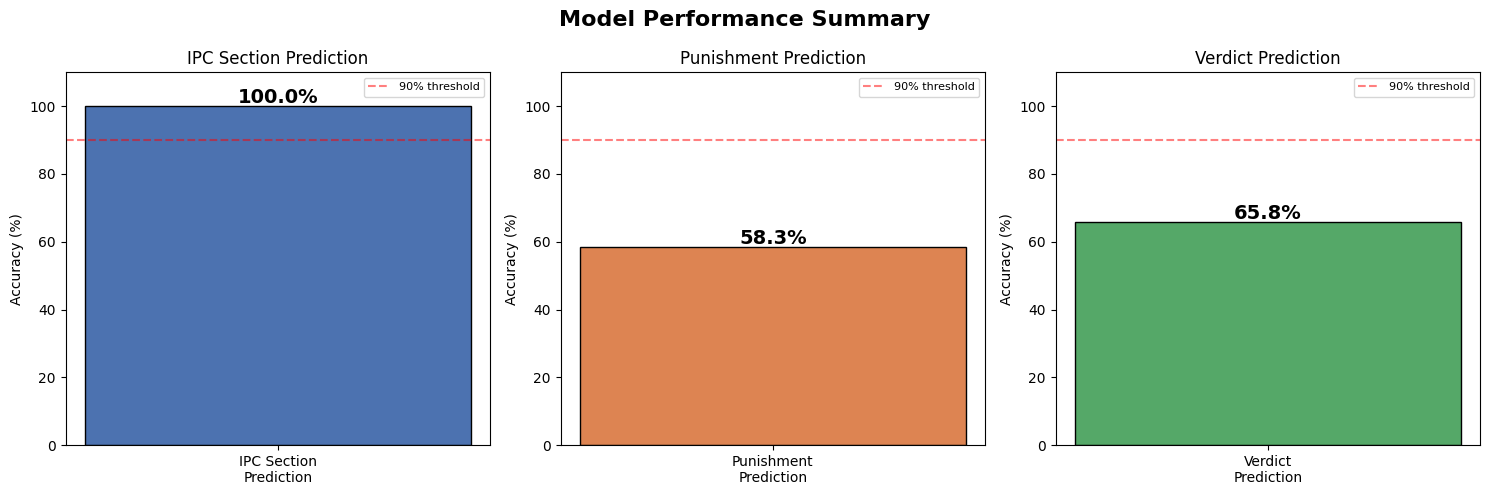


FINAL PERFORMANCE SUMMARY
  IPC Section Prediction Accuracy  : 1.0000  (100.0%)
  Punishment Category Accuracy     : 0.5833  (58.3%)
  Verdict Prediction Accuracy      : 0.6583  (65.8%)


In [22]:
# CELL 19 — Model Performance Summary Dashboard

ipc_acc     = accuracy_score(y_ipc_test, y_ipc_pred)
pun_acc     = accuracy_score(y_pun_test, y_pun_pred)
verdict_acc = accuracy_score(y_v_test,   y_v_pred)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Performance Summary", fontsize=16, fontweight="bold")

modules = ["IPC Section\nPrediction", "Punishment\nPrediction", "Verdict\nPrediction"]
accs    = [ipc_acc, pun_acc, verdict_acc]
colors  = ["#4c72b0", "#dd8452", "#55a868"]

for ax, mod, acc, col in zip(axes, modules, accs, colors):
    ax.bar([mod], [acc * 100], color=col, edgecolor="black", width=0.4)
    ax.set_ylim(0, 110)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(mod.replace("\n", " "))
    ax.text(0, acc * 100 + 1, f"{acc:.1%}", ha="center",
            fontsize=14, fontweight="bold")
    ax.axhline(y=90, color="red", linestyle="--",
               alpha=0.5, label="90% threshold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("model_performance_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 55)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  IPC Section Prediction Accuracy  : {ipc_acc:.4f}  ({ipc_acc:.1%})")
print(f"  Punishment Category Accuracy     : {pun_acc:.4f}  ({pun_acc:.1%})")
print(f"  Verdict Prediction Accuracy      : {verdict_acc:.4f}  ({verdict_acc:.1%})")
print("=" * 55)

In [23]:
# CELL 20 — Save All Trained Models

import joblib

joblib.dump(ipc_rf_model,     "ipc_rf_model.pkl")
joblib.dump(ipc_tfidf,        "ipc_tfidf.pkl")
joblib.dump(pun_rf_model,     "pun_rf_model.pkl")
joblib.dump(pun_tfidf,        "pun_tfidf.pkl")
joblib.dump(verdict_rf_model, "verdict_rf_model.pkl")
joblib.dump(verdict_tfidf,    "verdict_tfidf.pkl")
joblib.dump(le_verdict,       "label_encoder_verdict.pkl")

print("✅ All models saved!")
print()
print("Files saved:")
print("  ipc_rf_model.pkl        — IPC section classifier")
print("  ipc_tfidf.pkl           — IPC TF-IDF vectorizer")
print("  pun_rf_model.pkl        — Punishment classifier")
print("  pun_tfidf.pkl           — Punishment TF-IDF vectorizer")
print("  verdict_rf_model.pkl    — Verdict classifier")
print("  verdict_tfidf.pkl       — Verdict TF-IDF vectorizer")
print("  label_encoder_verdict.pkl — Label encoder")
print()
print("To download: Files panel (left sidebar) → right-click → Download")

✅ All models saved!

Files saved:
  ipc_rf_model.pkl        — IPC section classifier
  ipc_tfidf.pkl           — IPC TF-IDF vectorizer
  pun_rf_model.pkl        — Punishment classifier
  pun_tfidf.pkl           — Punishment TF-IDF vectorizer
  verdict_rf_model.pkl    — Verdict classifier
  verdict_tfidf.pkl       — Verdict TF-IDF vectorizer
  label_encoder_verdict.pkl — Label encoder

To download: Files panel (left sidebar) → right-click → Download
